# 🎵 Spotify Hit Predictor

## Notebook 3 — Modelado base y evaluación inicial

**Rol responsable:**  Data Scientist  
**Apoyo técnico:**  ML Engineer & Ethics/Impact Lead

---

### Objetivo del notebook

En este notebook se construirá el pipeline de preprocesamiento y se entrenarán los primeros modelos de clasificación para predecir si una canción será popular.

Se compararán, como mínimo:

1. `DummyClassifier` como baseline.
2. Regresión Logística como modelo interpretable inicial.

La comparación se realizará utilizando únicamente los conjuntos de entrenamiento y validación. El conjunto de test permanecerá reservado para la evaluación final.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MultiLabelBinarizer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

df_model = pd.read_csv("../data/processed/spotify_model_dataset.csv")

print("Dimensión del dataset:", df_model.shape)
df_model.head()

Dimensión del dataset: (89730, 24)


,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,...,liveness,valence,tempo,time_signature,popularity,genres,popular,rhythm_missing,energy_tempo,is_long_track
0,0000vdREvCVMxbQTkS888c,Rill,Lolly,Lolly,160725,True,0.910,0.374,8,-9.844,...,0.1540,0.432,104.042,4.0,44.0,german,0,0,38.911708,0
1,000CC8EParg64OmTxVnZ0p,Glee Cast,Glee Love Songs,It's All Coming Back To Me Now (Glee Cast Vers...,322933,False,0.269,0.516,0,-7.361,...,0.1170,0.341,178.174,4.0,47.0,club,0,0,91.937784,0
2,000Iz0K615UepwSJ5z2RE5,Paul Kalkbrenner;Pig&Dan,X,Böxig Leise - Pig & Dan Remix,515360,False,0.686,0.560,5,-13.264,...,0.1110,0.108,119.997,4.0,22.0,minimal-techno,0,0,67.198320,0
3,000RDCYioLteXcutOjeweY,Jordan Sandhu,Teeje Week,Teeje Week,190203,False,0.679,0.770,0,-3.537,...,0.0825,0.839,161.721,4.0,62.0,hip-hop,1,0,124.525170,0
4,000qpdoc97IMTBvF8gwcpy,Paul Kalkbrenner,Zeit,Tief,331240,False,0.519,0.431,6,-13.606,...,0.0916,0.234,129.971,4.0,19.0,minimal-techno,0,0,56.017501,0


In [2]:
# Variables que no entran como predictores
reference_columns = [
    "track_id",
    "artists",
    "album_name",
    "track_name",
    "popularity"
]

# Variables que utilizarán los modelos
feature_columns = [
    "duration_ms",
    "explicit",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature",
    "genres",
    "rhythm_missing",
    "energy_tempo",
    "is_long_track"
]

target_column = "popular"

X = df_model[feature_columns].copy()
y = df_model[target_column].copy()
reference_data = df_model[reference_columns].copy()

# 15% reservado para test
X_train_val, X_test, y_train_val, y_test, ref_train_val, ref_test = train_test_split(
    X,
    y,
    reference_data,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Del 85% restante: aproximadamente 70% train y 15% validation
X_train, X_val, y_train, y_val, ref_train, ref_val = train_test_split(
    X_train_val,
    y_train_val,
    ref_train_val,
    test_size=0.1765,
    random_state=42,
    stratify=y_train_val
)

print("Train:", X_train.shape, f"| populares: {y_train.mean():.2%}")
print("Validation:", X_val.shape, f"| populares: {y_val.mean():.2%}")
print("Test:", X_test.shape, f"| populares: {y_test.mean():.2%}")

Train: (62808, 18) | populares: 23.63%
Validation: (13462, 18) | populares: 23.63%
Test: (13460, 18) | populares: 23.63%


## Baseline: DummyClassifier

Antes de entrenar modelos predictivos, se utilizará un `DummyClassifier` con estrategia `most_frequent`.

Este modelo siempre predice la clase mayoritaria (`popular = 0`) y sirve como referencia mínima. Un modelo útil debe superar claramente este baseline, especialmente en métricas relacionadas con la detección de canciones populares.

In [3]:
# Baseline que siempre predice la clase más frecuente
dummy_model = DummyClassifier(strategy="most_frequent", random_state=42)

# El DummyClassifier no necesita las features reales,
# por eso usamos una columna auxiliar de ceros.
X_train_dummy = np.zeros((len(X_train), 1))
X_val_dummy = np.zeros((len(X_val), 1))

dummy_model.fit(X_train_dummy, y_train)

y_val_pred_dummy = dummy_model.predict(X_val_dummy)
y_val_proba_dummy = dummy_model.predict_proba(X_val_dummy)[:, 1]

print("Predicción única del baseline:", np.unique(y_val_pred_dummy))

Predicción única del baseline: [0]


In [4]:
def calculate_metrics(y_true, y_pred, y_proba, model_name):
    return {
        "Modelo": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba)
    }

dummy_metrics = calculate_metrics(
    y_val,
    y_val_pred_dummy,
    y_val_proba_dummy,
    "DummyClassifier"
)

baseline_results = pd.DataFrame([dummy_metrics])
baseline_results.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}",
    "ROC-AUC": "{:.3f}",
    "PR-AUC": "{:.3f}"
})

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,DummyClassifier,76.37%,0.00%,0.00%,0.00%,0.500,0.236


## Regresión Logística — modelo interpretable inicial

Como primer modelo predictivo se utilizará una Regresión Logística con variables musicales numéricas y binarias.

En esta primera versión no se incluyen `track_id`, artistas, álbumes, nombres de canciones ni `genres`:

- Los identificadores y textos de artistas/álbumes tienen alta cardinalidad.
- `popularity` no puede entrar como predictor porque se usa para crear la variable objetivo.
- `genres` se incorporará en una versión posterior mediante una codificación multi-etiqueta, ajustada solo con los datos de entrenamiento.

Los valores faltantes de `tempo`, `time_signature` y `energy_tempo` se imputarán dentro del pipeline. Esto evita fuga de información desde validation o test.

In [5]:
# Features numéricas y binarias para el primer modelo interpretable
numeric_features = [
    "duration_ms",
    "explicit",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature",
    "rhythm_missing",
    "energy_tempo",
    "is_long_track"
]

# Imputación + escalado dentro del pipeline
numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_logistic = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, numeric_features)
    ],
    remainder="drop"
)

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor_logistic),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

logistic_model.fit(X_train, y_train)

print("Regresión Logística entrenada correctamente.")

Regresión Logística entrenada correctamente.


In [6]:
# Predicciones de la Regresión Logística sobre validation
y_val_pred_logistic = logistic_model.predict(X_val)
y_val_proba_logistic = logistic_model.predict_proba(X_val)[:, 1]

logistic_metrics = calculate_metrics(
    y_val,
    y_val_pred_logistic,
    y_val_proba_logistic,
    "Logistic Regression"
)

comparison_results = pd.DataFrame([
    dummy_metrics,
    logistic_metrics
])

comparison_results.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}",
    "ROC-AUC": "{:.3f}",
    "PR-AUC": "{:.3f}"
})

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,DummyClassifier,76.37%,0.00%,0.00%,0.00%,0.500,0.236
1,Logistic Regression,57.35%,30.40%,62.43%,40.89%,0.631,0.336


### Interpretación inicial

La Regresión Logística supera al baseline en todas las métricas relevantes para la clase positiva.

Aunque su accuracy es menor que la del `DummyClassifier`, el baseline obtiene una accuracy alta únicamente porque predice todas las canciones como no populares. En contraste, la Regresión Logística identifica el 62,43% de las canciones populares en validation.

Por ello, para este problema se priorizarán métricas como recall, F1-score, ROC-AUC y PR-AUC, en lugar de utilizar accuracy como único criterio de selección.

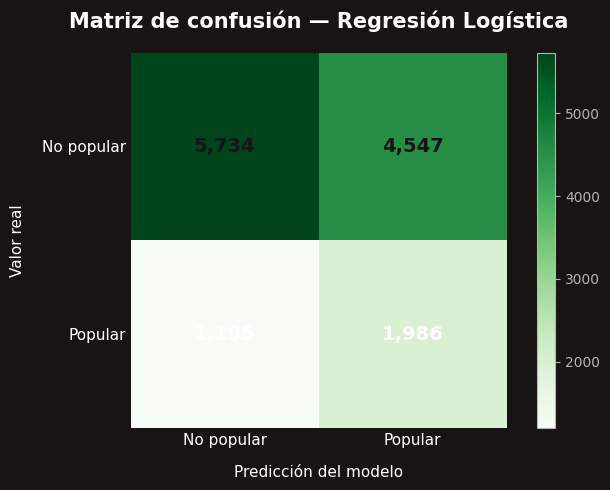

In [8]:
# Matriz de confusión con estilo Spotify

cm_logistic = confusion_matrix(y_val, y_val_pred_logistic)

spotify_green = "#1DB954"
spotify_black = "#191414"
spotify_dark = "#121212"
spotify_gray = "#B3B3B3"
spotify_white = "#FFFFFF"

fig, ax = plt.subplots(figsize=(7, 5))

fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

image = ax.imshow(
    cm_logistic,
    cmap="Greens"
)

ax.set_title(
    "Matriz de confusión — Regresión Logística",
    fontsize=15,
    fontweight="bold",
    color=spotify_white,
    pad=18
)

ax.set_xlabel(
    "Predicción del modelo",
    fontsize=11,
    color=spotify_white,
    labelpad=12
)

ax.set_ylabel(
    "Valor real",
    fontsize=11,
    color=spotify_white,
    labelpad=12
)

ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["No popular", "Popular"],
    fontsize=11,
    color=spotify_white
)

ax.set_yticks([0, 1])
ax.set_yticklabels(
    ["No popular", "Popular"],
    fontsize=11,
    color=spotify_white
)

for i in range(cm_logistic.shape[0]):
    for j in range(cm_logistic.shape[1]):
        value = cm_logistic[i, j]

        text_color = spotify_black if value > cm_logistic.max() / 2 else spotify_white

        ax.text(
            j,
            i,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color=text_color
        )

colorbar = fig.colorbar(image)
colorbar.ax.tick_params(colors=spotify_gray)
colorbar.outline.set_edgecolor(spotify_gray)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0)

plt.tight_layout()
plt.show()

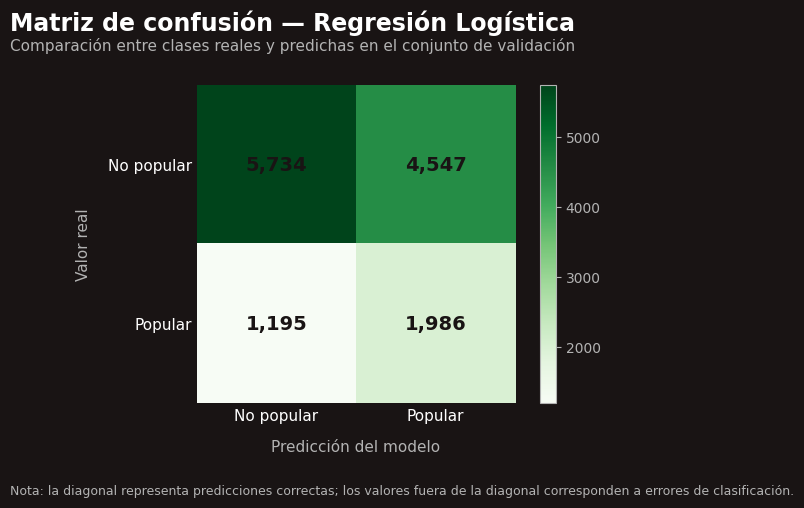

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Matriz de confusión con estilo Spotify
cm_logistic = confusion_matrix(y_val, y_val_pred_logistic)

spotify_green = "#1DB954"
spotify_black = "#191414"
spotify_dark = "#121212"
spotify_gray = "#B3B3B3"
spotify_white = "#FFFFFF"

fig, ax = plt.subplots(figsize=(7, 5))

# Fondos
fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

# Heatmap
image = ax.imshow(
    cm_logistic,
    cmap="Greens"
)

# Título y subtítulo
fig.text(
    0.125,
    0.96,
    "Matriz de confusión — Regresión Logística",
    color=spotify_white,
    fontsize=17,
    fontweight="bold"
)

fig.text(
    0.125,
    0.92,
    "Comparación entre clases reales y predichas en el conjunto de validación",
    color=spotify_gray,
    fontsize=11
)

# Etiquetas de ejes
ax.set_xlabel(
    "Predicción del modelo",
    fontsize=11,
    color=spotify_gray,
    labelpad=12
)

ax.set_ylabel(
    "Valor real",
    fontsize=11,
    color=spotify_gray,
    labelpad=12
)

# Ticks
ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["No popular", "Popular"],
    fontsize=11,
    color=spotify_white
)

ax.set_yticks([0, 1])
ax.set_yticklabels(
    ["No popular", "Popular"],
    fontsize=11,
    color=spotify_white
)

# Valores dentro de las celdas
threshold = cm_logistic.max() / 2

for i in range(cm_logistic.shape[0]):
    for j in range(cm_logistic.shape[1]):
        value = cm_logistic[i, j]
        text_color = spotify_black

        ax.text(
            j,
            i,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color=text_color
        )

# Colorbar
colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.ax.tick_params(colors=spotify_gray, labelsize=10)
colorbar.outline.set_edgecolor(spotify_gray)

# Quitar bordes y marcas
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0)

# Nota
fig.text(
    0.125,
    0.03,
    "Nota: la diagonal representa predicciones correctas; los valores fuera de la diagonal corresponden a errores de clasificación.",
    color=spotify_gray,
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 0.88])

plt.savefig(
    "../reports/figures/confusion_matrix_logistic_spotify_style.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

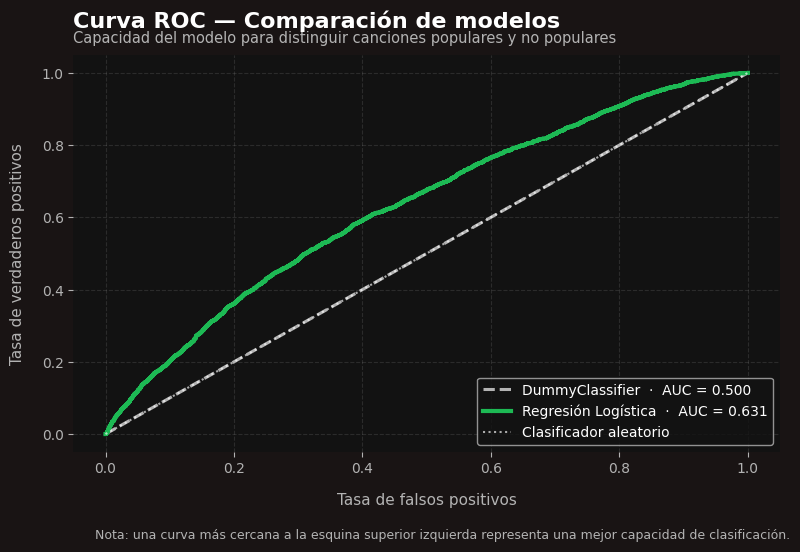

In [11]:
from sklearn.metrics import roc_curve

# Curvas ROC
fpr_dummy, tpr_dummy, _ = roc_curve(y_val, y_val_proba_dummy)
fpr_logistic, tpr_logistic, _ = roc_curve(y_val, y_val_proba_logistic)

spotify_green = "#1DB954"
spotify_black = "#191414"
spotify_dark = "#121212"
spotify_gray = "#B3B3B3"
spotify_white = "#FFFFFF"

fig, ax = plt.subplots(figsize=(8, 5.5))

fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

ax.plot(
    fpr_dummy,
    tpr_dummy,
    linestyle="--",
    linewidth=2.2,
    color=spotify_gray,
    label="DummyClassifier  ·  AUC = 0.500"
)

ax.plot(
    fpr_logistic,
    tpr_logistic,
    linewidth=3,
    color=spotify_green,
    label="Regresión Logística  ·  AUC = 0.631"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    linewidth=1.5,
    color=spotify_white,
    alpha=0.65,
    label="Clasificador aleatorio"
)

ax.set_title(
    "Curva ROC — Comparación de modelos",
    fontsize=16,
    fontweight="bold",
    color=spotify_white,
    loc="left",
    pad=20
)

ax.text(
    0,
    1.03,
    "Capacidad del modelo para distinguir canciones populares y no populares",
    transform=ax.transAxes,
    fontsize=10.5,
    color=spotify_gray
)

ax.set_xlabel(
    "Tasa de falsos positivos",
    fontsize=11,
    color=spotify_gray,
    labelpad=12
)

ax.set_ylabel(
    "Tasa de verdaderos positivos",
    fontsize=11,
    color=spotify_gray,
    labelpad=12
)

ax.tick_params(colors=spotify_gray)

ax.grid(
    alpha=0.16,
    color=spotify_gray,
    linestyle="--"
)

legend = ax.legend(
    facecolor=spotify_dark,
    edgecolor=spotify_gray,
    labelcolor=spotify_white,
    loc="lower right",
    fontsize=10
)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(
    0.125,
    0.01,
    "Nota: una curva más cercana a la esquina superior izquierda representa una mejor capacidad de clasificación.",
    fontsize=9,
    color=spotify_gray
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

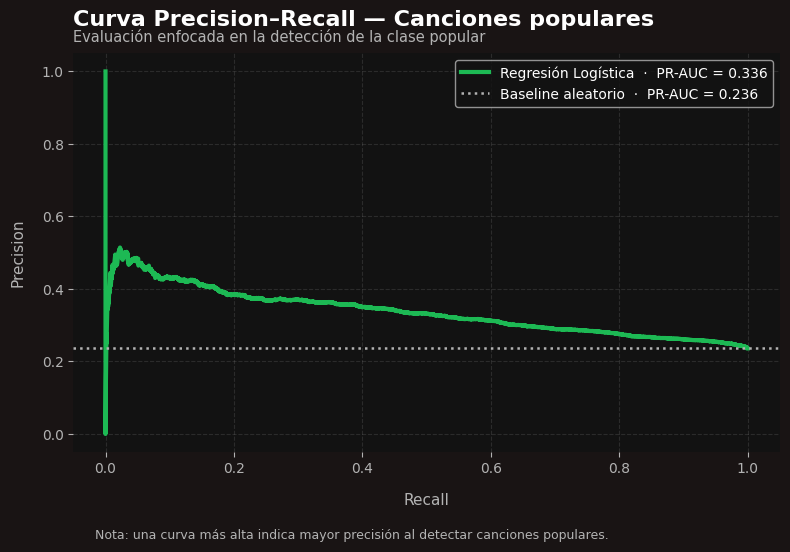

In [13]:
from sklearn.metrics import precision_recall_curve

precision_logistic, recall_logistic, _ = precision_recall_curve(
    y_val,
    y_val_proba_logistic
)

baseline_positive_rate = y_val.mean()

fig, ax = plt.subplots(figsize=(8, 5.5))

fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

ax.plot(
    recall_logistic,
    precision_logistic,
    linewidth=3,
    color=spotify_green,
    label=f"Regresión Logística  ·  PR-AUC = {logistic_metrics['PR-AUC']:.3f}"
)

ax.axhline(
    baseline_positive_rate,
    linestyle=":",
    linewidth=1.8,
    color=spotify_gray,
    label=f"Baseline aleatorio  ·  PR-AUC = {baseline_positive_rate:.3f}"
)

ax.set_title(
    "Curva Precision–Recall — Canciones populares",
    fontsize=16,
    fontweight="bold",
    color=spotify_white,
    loc="left",
    pad=20
)

ax.text(
    0,
    1.03,
    "Evaluación enfocada en la detección de la clase popular",
    transform=ax.transAxes,
    fontsize=10.5,
    color=spotify_gray
)

ax.set_xlabel(
    "Recall",
    fontsize=11,
    color=spotify_gray,
    labelpad=12
)

ax.set_ylabel(
    "Precision",
    fontsize=11,
    color=spotify_gray,
    labelpad=12
)

ax.tick_params(colors=spotify_gray)

ax.grid(
    alpha=0.16,
    color=spotify_gray,
    linestyle="--"
)

ax.legend(
    facecolor=spotify_dark,
    edgecolor=spotify_gray,
    labelcolor=spotify_white,
    loc="upper right",
    fontsize=10
)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(
    0.125,
    0.01,
    "Nota: una curva más alta indica mayor precisión al detectar canciones populares.",
    fontsize=9,
    color=spotify_gray
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## Interpretabilidad del modelo

La Regresión Logística permite revisar la dirección e intensidad de cada feature:

- Un coeficiente positivo aumenta la probabilidad estimada de que una canción sea popular.
- Un coeficiente negativo la reduce.
- Como las variables numéricas fueron escaladas, los coeficientes pueden compararse entre sí.

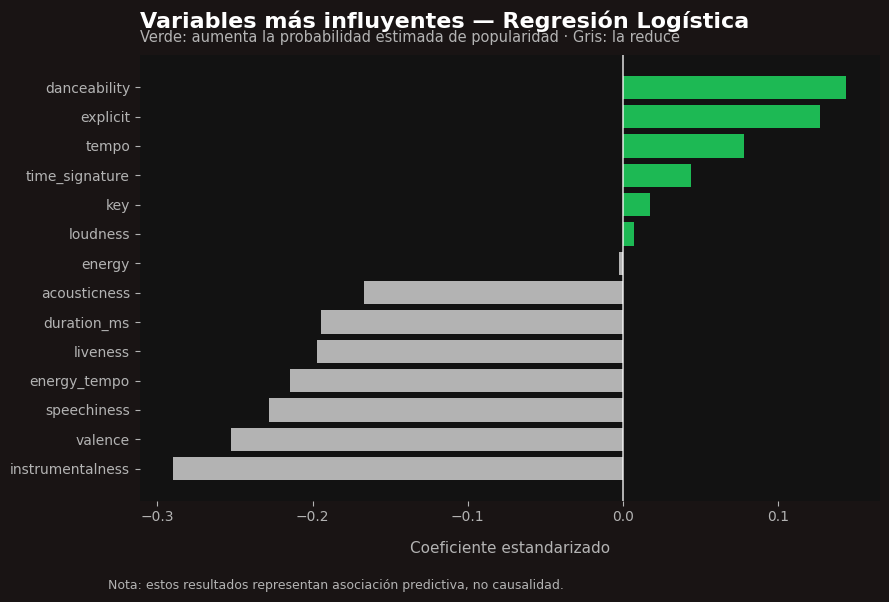

,Feature,Coeficiente
0,instrumentalness,-0.289611
1,valence,-0.252423
2,speechiness,-0.227736
3,energy_tempo,-0.214819
4,liveness,-0.196988
5,duration_ms,-0.194511
6,acousticness,-0.166862
16,danceability,0.143760
15,explicit,0.126721
14,tempo,0.077849


In [14]:
# Coeficientes de la Regresión Logística

feature_names_logistic = logistic_model.named_steps["preprocessor"].get_feature_names_out()

coefficients_logistic = pd.DataFrame({
    "Feature": feature_names_logistic,
    "Coeficiente": logistic_model.named_steps["model"].coef_[0]
})

coefficients_logistic["Feature"] = coefficients_logistic["Feature"].str.replace(
    "numeric__", "",
    regex=False
)

coefficients_logistic = coefficients_logistic.sort_values(
    "Coeficiente"
).reset_index(drop=True)

top_coefficients = pd.concat([
    coefficients_logistic.head(7),
    coefficients_logistic.tail(7)
]).sort_values("Coeficiente")

fig, ax = plt.subplots(figsize=(9, 6))

fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

bar_colors = [
    spotify_gray if value < 0 else spotify_green
    for value in top_coefficients["Coeficiente"]
]

ax.barh(
    top_coefficients["Feature"],
    top_coefficients["Coeficiente"],
    color=bar_colors
)

ax.axvline(
    0,
    color=spotify_white,
    linewidth=1.2,
    alpha=0.8
)

ax.set_title(
    "Variables más influyentes — Regresión Logística",
    fontsize=16,
    fontweight="bold",
    color=spotify_white,
    loc="left",
    pad=20
)

ax.text(
    0,
    1.03,
    "Verde: aumenta la probabilidad estimada de popularidad · Gris: la reduce",
    transform=ax.transAxes,
    fontsize=10.5,
    color=spotify_gray
)

ax.set_xlabel(
    "Coeficiente estandarizado",
    fontsize=11,
    color=spotify_gray,
    labelpad=12
)

ax.set_ylabel("")
ax.tick_params(colors=spotify_gray)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(
    0.125,
    0.01,
    "Nota: estos resultados representan asociación predictiva, no causalidad.",
    fontsize=9,
    color=spotify_gray
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

coefficients_logistic.sort_values(
    "Coeficiente",
    key=abs,
    ascending=False
)

## Selección de umbral de decisión

La Regresión Logística genera una probabilidad estimada de popularidad para cada canción.

El umbral predeterminado es `0.50`; sin embargo, se evaluarán distintos valores usando únicamente validation. La selección se basará inicialmente en el mayor F1-score, porque equilibra precision y recall para la clase popular.

In [15]:
# Evaluación de distintos umbrales usando únicamente validation

thresholds = np.arange(0.30, 0.71, 0.05)
threshold_results = []

for threshold in thresholds:
    y_val_pred_threshold = (y_val_proba_logistic >= threshold).astype(int)

    threshold_results.append({
        "Umbral": round(threshold, 2),
        "Precision": precision_score(y_val, y_val_pred_threshold, zero_division=0),
        "Recall": recall_score(y_val, y_val_pred_threshold, zero_division=0),
        "F1-score": f1_score(y_val, y_val_pred_threshold, zero_division=0),
        "Canciones_predichas_populares": int(y_val_pred_threshold.sum())
    })

threshold_results = pd.DataFrame(threshold_results)

best_threshold_row = threshold_results.loc[
    threshold_results["F1-score"].idxmax()
]

print(
    f"Mejor umbral por F1-score: {best_threshold_row['Umbral']:.2f} "
    f"| F1-score: {best_threshold_row['F1-score']:.2%}"
)

threshold_results.style.format({
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}"
})

Mejor umbral por F1-score: 0.45 | F1-score: 41.34%


,Umbral,Precision,Recall,F1-score,Canciones_predichas_populares
0,0.300000,24.90%,97.45%,39.66%,12450
1,0.350000,25.63%,94.00%,40.27%,11668
2,0.400000,26.46%,86.45%,40.52%,10393
3,0.450000,28.34%,76.39%,41.34%,8575
4,0.500000,30.40%,62.43%,40.89%,6533
5,0.550000,33.75%,45.99%,38.93%,4335
6,0.600000,37.02%,26.41%,30.83%,2269
7,0.650000,42.14%,12.39%,19.14%,935
8,0.700000,47.88%,4.62%,8.43%,307


### Decisión preliminar de umbral

Se selecciona provisionalmente el umbral de **0.45** para la Regresión Logística, debido a que obtuvo el mayor F1-score en validation.

Con este umbral, el modelo detecta el 76,39% de las canciones populares, manteniendo una precisión de 28,34%. Esta decisión prioriza identificar posibles canciones con potencial de popularidad, aun cuando implique revisar una cantidad mayor de candidatos.

El umbral podrá revisarse después de comparar modelos más avanzados y realizar la simulación de impacto de negocio.

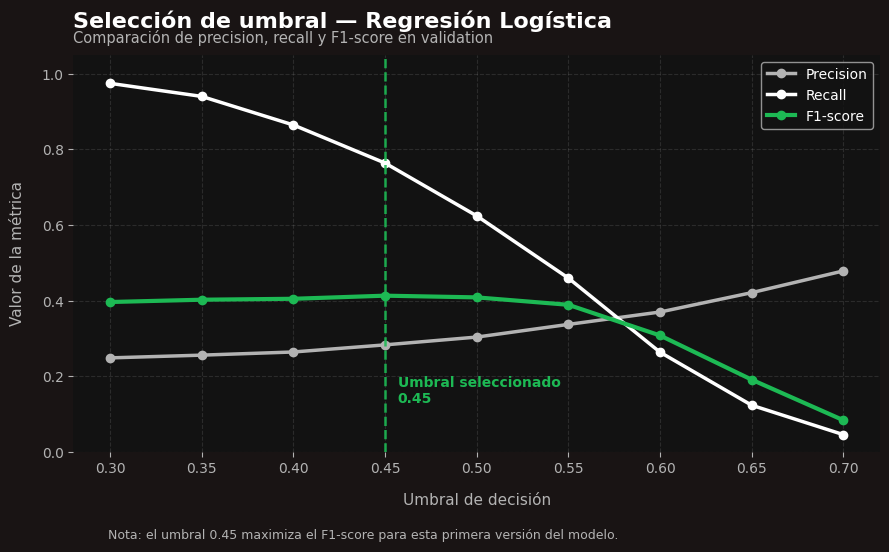

In [16]:
# Comparación de métricas según el umbral de decisión

fig, ax = plt.subplots(figsize=(9, 5.5))

fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

ax.plot(
    threshold_results["Umbral"],
    threshold_results["Precision"],
    marker="o",
    linewidth=2.5,
    label="Precision",
    color=spotify_gray
)

ax.plot(
    threshold_results["Umbral"],
    threshold_results["Recall"],
    marker="o",
    linewidth=2.5,
    label="Recall",
    color=spotify_white
)

ax.plot(
    threshold_results["Umbral"],
    threshold_results["F1-score"],
    marker="o",
    linewidth=3,
    label="F1-score",
    color=spotify_green
)

ax.axvline(
    0.45,
    color=spotify_green,
    linestyle="--",
    linewidth=1.8,
    alpha=0.9
)

ax.text(
    0.457,
    0.13,
    "Umbral seleccionado\n0.45",
    color=spotify_green,
    fontsize=10,
    fontweight="bold"
)

ax.set_title(
    "Selección de umbral — Regresión Logística",
    fontsize=16,
    fontweight="bold",
    color=spotify_white,
    loc="left",
    pad=20
)

ax.text(
    0,
    1.03,
    "Comparación de precision, recall y F1-score en validation",
    transform=ax.transAxes,
    fontsize=10.5,
    color=spotify_gray
)

ax.set_xlabel(
    "Umbral de decisión",
    fontsize=11,
    color=spotify_gray,
    labelpad=12
)

ax.set_ylabel(
    "Valor de la métrica",
    fontsize=11,
    color=spotify_gray,
    labelpad=12
)

ax.set_xticks(threshold_results["Umbral"])
ax.set_ylim(0, 1.05)
ax.tick_params(colors=spotify_gray)

ax.grid(
    alpha=0.16,
    color=spotify_gray,
    linestyle="--"
)

ax.legend(
    facecolor=spotify_dark,
    edgecolor=spotify_gray,
    labelcolor=spotify_white,
    loc="upper right"
)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(
    0.125,
    0.01,
    "Nota: el umbral 0.45 maximiza el F1-score para esta primera versión del modelo.",
    fontsize=9,
    color=spotify_gray
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## Incorporación de géneros musicales

Una canción puede pertenecer a más de un género. Por ello, la variable `genres` se convertirá en múltiples columnas binarias mediante `MultiLabelBinarizer`.

El codificador se ajustará únicamente con el conjunto de entrenamiento. De este modo, validation y test no influyen en la creación de las features.

In [17]:
# Preparación de géneros multi-etiqueta sin fuga de información

def split_genres(series):
    return series.fillna("").apply(
        lambda value: [genre for genre in value.split("|") if genre]
    )

genres_train = split_genres(X_train["genres"])
genres_val = split_genres(X_val["genres"])
genres_test = split_genres(X_test["genres"])

mlb = MultiLabelBinarizer()

genres_train_encoded = mlb.fit_transform(genres_train)
genres_val_encoded = mlb.transform(genres_val)
genres_test_encoded = mlb.transform(genres_test)

print("Número de géneros aprendidos en train:", len(mlb.classes_))
print("Shape train:", genres_train_encoded.shape)
print("Shape validation:", genres_val_encoded.shape)
print("Primeros géneros:", list(mlb.classes_[:10]))

Número de géneros aprendidos en train: 114
Shape train: (62808, 114)
Shape validation: (13462, 114)
Primeros géneros: ['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime', 'black-metal', 'bluegrass', 'blues', 'brazil']


## Regresión Logística con audio features y géneros

En esta segunda versión, se incorporan los géneros musicales codificados junto con las variables numéricas y binarias.

El preprocesamiento numérico se ajusta únicamente con `train`; después, sus resultados se combinan con la matriz de géneros creada mediante `MultiLabelBinarizer`.

In [18]:
from scipy.sparse import csr_matrix, hstack

# Ajustar el preprocesador numérico solo con train
X_train_numeric = preprocessor_logistic.fit_transform(X_train)
X_val_numeric = preprocessor_logistic.transform(X_val)
X_test_numeric = preprocessor_logistic.transform(X_test)

# Combinar audio features + géneros
X_train_with_genres = hstack([
    csr_matrix(X_train_numeric),
    csr_matrix(genres_train_encoded)
])

X_val_with_genres = hstack([
    csr_matrix(X_val_numeric),
    csr_matrix(genres_val_encoded)
])

X_test_with_genres = hstack([
    csr_matrix(X_test_numeric),
    csr_matrix(genres_test_encoded)
])

print("Train con géneros:", X_train_with_genres.shape)
print("Validation con géneros:", X_val_with_genres.shape)
print("Test con géneros:", X_test_with_genres.shape)

Train con géneros: (62808, 131)
Validation con géneros: (13462, 131)
Test con géneros: (13460, 131)


In [19]:
# Regresión Logística con audio features + géneros

logistic_genres_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

logistic_genres_model.fit(X_train_with_genres, y_train)

y_val_pred_logistic_genres = logistic_genres_model.predict(X_val_with_genres)
y_val_proba_logistic_genres = logistic_genres_model.predict_proba(
    X_val_with_genres
)[:, 1]

logistic_genres_metrics = calculate_metrics(
    y_val,
    y_val_pred_logistic_genres,
    y_val_proba_logistic_genres,
    "Logistic Regression + Genres"
)

comparison_results_v2 = pd.DataFrame([
    dummy_metrics,
    logistic_metrics,
    logistic_genres_metrics
])

comparison_results_v2.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}",
    "ROC-AUC": "{:.3f}",
    "PR-AUC": "{:.3f}"
})

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,DummyClassifier,76.37%,0.00%,0.00%,0.00%,0.500,0.236
1,Logistic Regression,57.35%,30.40%,62.43%,40.89%,0.631,0.336
2,Logistic Regression + Genres,73.87%,46.88%,79.50%,58.98%,0.836,0.600


### Comparación: efecto de incorporar géneros

La Regresión Logística con géneros musicales obtuvo una mejora importante frente a la versión que utiliza únicamente audio features.

El F1-score aumentó de 40,89% a 58,98%, mientras que el ROC-AUC aumentó de 0,631 a 0,836. Además, el modelo ahora detecta el 79,50% de las canciones populares en validation.

Estos resultados indican que el género musical contiene información predictiva relevante para estimar la popularidad de una canción. Sin embargo, esta variable también deberá analizarse desde la perspectiva de fairness, ya que el desempeño puede variar entre géneros.

In [20]:
# Selección de umbral para Regresión Logística + Géneros

thresholds = np.arange(0.30, 0.71, 0.05)
threshold_results_genres = []

for threshold in thresholds:
    y_val_pred_threshold_genres = (
        y_val_proba_logistic_genres >= threshold
    ).astype(int)

    threshold_results_genres.append({
        "Umbral": round(threshold, 2),
        "Precision": precision_score(
            y_val,
            y_val_pred_threshold_genres,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            y_val_pred_threshold_genres,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_val,
            y_val_pred_threshold_genres,
            zero_division=0
        ),
        "Canciones_predichas_populares": int(
            y_val_pred_threshold_genres.sum()
        )
    })

threshold_results_genres = pd.DataFrame(threshold_results_genres)

best_threshold_genres = threshold_results_genres.loc[
    threshold_results_genres["F1-score"].idxmax()
]

print(
    f"Mejor umbral con géneros: {best_threshold_genres['Umbral']:.2f} "
    f"| F1-score: {best_threshold_genres['F1-score']:.2%}"
)

threshold_results_genres.style.format({
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}"
})

Mejor umbral con géneros: 0.55 | F1-score: 59.28%


,Umbral,Precision,Recall,F1-score,Canciones_predichas_populares
0,0.300000,37.66%,93.43%,53.68%,7892
1,0.350000,39.70%,91.01%,55.29%,7292
2,0.400000,42.18%,87.68%,56.96%,6612
3,0.450000,44.24%,83.62%,57.86%,6013
4,0.500000,46.88%,79.50%,58.98%,5395
5,0.550000,49.37%,74.16%,59.28%,4778
6,0.600000,52.00%,68.41%,59.08%,4185
7,0.650000,54.68%,61.33%,57.82%,3568
8,0.700000,59.32%,53.03%,56.00%,2844


### Decisión provisional de umbral — Modelo con géneros

Para la Regresión Logística con audio features y géneros se selecciona provisionalmente el umbral de **0.55**, debido a que obtuvo el mayor F1-score en validation.

Con este umbral, el modelo alcanzó:

- Precision: 49,37%
- Recall: 74,16%
- F1-score: 59,28%

La decisión podrá revisarse después de comparar este modelo con algoritmos no lineales y realizar la simulación de impacto de negocio.

In [21]:
from sklearn.ensemble import RandomForestClassifier

## Random Forest — modelo no lineal

Random Forest combina múltiples árboles de decisión para identificar relaciones no lineales e interacciones entre las características musicales y los géneros.

Se utilizarán las mismas 131 features preparadas para la Regresión Logística con géneros, de modo que la comparación sea justa.

In [22]:
# Random Forest con audio features + géneros

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=4,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_with_genres, y_train)

y_val_pred_rf = random_forest_model.predict(X_val_with_genres)
y_val_proba_rf = random_forest_model.predict_proba(
    X_val_with_genres
)[:, 1]

random_forest_metrics = calculate_metrics(
    y_val,
    y_val_pred_rf,
    y_val_proba_rf,
    "Random Forest + Genres"
)

comparison_results_v3 = pd.DataFrame([
    dummy_metrics,
    logistic_metrics,
    logistic_genres_metrics,
    random_forest_metrics
])

comparison_results_v3.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}",
    "ROC-AUC": "{:.3f}",
    "PR-AUC": "{:.3f}"
})

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,DummyClassifier,76.37%,0.00%,0.00%,0.00%,0.500,0.236
1,Logistic Regression,57.35%,30.40%,62.43%,40.89%,0.631,0.336
2,Logistic Regression + Genres,73.87%,46.88%,79.50%,58.98%,0.836,0.600
3,Random Forest + Genres,74.47%,47.41%,73.69%,57.70%,0.834,0.635


### Comparación inicial con Random Forest

El Random Forest con géneros obtuvo el mayor PR-AUC hasta el momento, con un valor de 0,635. Esto indica una mejor capacidad global para priorizar canciones populares frente a no populares.

Sin embargo, su F1-score con el umbral predeterminado de 0.50 fue ligeramente menor al de la Regresión Logística con géneros. Por ello, antes de seleccionar un modelo se evaluarán distintos umbrales de decisión utilizando validation.

In [23]:
# Selección de umbral para Random Forest + Géneros

thresholds = np.arange(0.30, 0.71, 0.05)
threshold_results_rf = []

for threshold in thresholds:
    y_val_pred_threshold_rf = (y_val_proba_rf >= threshold).astype(int)

    threshold_results_rf.append({
        "Umbral": round(threshold, 2),
        "Precision": precision_score(
            y_val,
            y_val_pred_threshold_rf,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            y_val_pred_threshold_rf,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_val,
            y_val_pred_threshold_rf,
            zero_division=0
        ),
        "Canciones_predichas_populares": int(
            y_val_pred_threshold_rf.sum()
        )
    })

threshold_results_rf = pd.DataFrame(threshold_results_rf)

best_threshold_rf = threshold_results_rf.loc[
    threshold_results_rf["F1-score"].idxmax()
]

print(
    f"Mejor umbral Random Forest: {best_threshold_rf['Umbral']:.2f} "
    f"| F1-score: {best_threshold_rf['F1-score']:.2%}"
)

threshold_results_rf.style.format({
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}"
})

Mejor umbral Random Forest: 0.50 | F1-score: 57.70%


,Umbral,Precision,Recall,F1-score,Canciones_predichas_populares
0,0.300000,28.03%,99.21%,43.71%,11259
1,0.350000,30.02%,98.21%,45.99%,10405
2,0.400000,33.13%,96.01%,49.27%,9217
3,0.450000,37.59%,91.01%,53.21%,7701
4,0.500000,47.41%,73.69%,57.70%,4944
5,0.550000,68.28%,44.86%,54.15%,2090
6,0.600000,75.70%,33.79%,46.73%,1420
7,0.650000,79.59%,24.27%,37.20%,970
8,0.700000,80.59%,16.32%,27.14%,644


In [24]:
from sklearn.ensemble import HistGradientBoostingClassifier

## HistGradientBoosting — modelo de boosting

HistGradientBoosting construye árboles de forma secuencial: cada nuevo árbol intenta corregir los errores del anterior.

Este modelo permitirá evaluar si una estrategia de boosting mejora la detección de canciones populares frente a la Regresión Logística y Random Forest.

In [25]:
# HistGradientBoosting requiere una matriz densa
X_train_dense = X_train_with_genres.toarray().astype("float32")
X_val_dense = X_val_with_genres.toarray().astype("float32")

hist_gradient_model = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=250,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    class_weight="balanced",
    random_state=42
)

hist_gradient_model.fit(X_train_dense, y_train)

y_val_pred_hgb = hist_gradient_model.predict(X_val_dense)
y_val_proba_hgb = hist_gradient_model.predict_proba(X_val_dense)[:, 1]

hist_gradient_metrics = calculate_metrics(
    y_val,
    y_val_pred_hgb,
    y_val_proba_hgb,
    "HistGradientBoosting + Genres"
)

comparison_results_v4 = pd.DataFrame([
    dummy_metrics,
    logistic_metrics,
    logistic_genres_metrics,
    random_forest_metrics,
    hist_gradient_metrics
])

comparison_results_v4.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}",
    "ROC-AUC": "{:.3f}",
    "PR-AUC": "{:.3f}"
})

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,DummyClassifier,76.37%,0.00%,0.00%,0.00%,0.500,0.236
1,Logistic Regression,57.35%,30.40%,62.43%,40.89%,0.631,0.336
2,Logistic Regression + Genres,73.87%,46.88%,79.50%,58.98%,0.836,0.600
3,Random Forest + Genres,74.47%,47.41%,73.69%,57.70%,0.834,0.635
4,HistGradientBoosting + Genres,77.88%,52.05%,80.86%,63.33%,0.871,0.674


### Resultado inicial de HistGradientBoosting

HistGradientBoosting con audio features y géneros obtuvo el mejor desempeño entre los modelos evaluados hasta el momento.

En validation alcanzó un F1-score de 63,33%, ROC-AUC de 0,871 y PR-AUC de 0,674. Además, detectó el 80,86% de las canciones populares.

Por estos resultados, HistGradientBoosting se considera el modelo candidato principal. Sin embargo, antes de seleccionarlo definitivamente se ajustará su umbral de decisión y posteriormente se realizará tuning de hiperparámetros.

In [26]:
# Selección de umbral para HistGradientBoosting + Géneros

thresholds = np.arange(0.30, 0.71, 0.05)
threshold_results_hgb = []

for threshold in thresholds:
    y_val_pred_threshold_hgb = (
        y_val_proba_hgb >= threshold
    ).astype(int)

    threshold_results_hgb.append({
        "Umbral": round(threshold, 2),
        "Precision": precision_score(
            y_val,
            y_val_pred_threshold_hgb,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            y_val_pred_threshold_hgb,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_val,
            y_val_pred_threshold_hgb,
            zero_division=0
        ),
        "Canciones_predichas_populares": int(
            y_val_pred_threshold_hgb.sum()
        )
    })

threshold_results_hgb = pd.DataFrame(threshold_results_hgb)

best_threshold_hgb = threshold_results_hgb.loc[
    threshold_results_hgb["F1-score"].idxmax()
]

print(
    f"Mejor umbral HistGradientBoosting: "
    f"{best_threshold_hgb['Umbral']:.2f} "
    f"| F1-score: {best_threshold_hgb['F1-score']:.2%}"
)

threshold_results_hgb.style.format({
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}"
})

Mejor umbral HistGradientBoosting: 0.55 | F1-score: 64.14%


,Umbral,Precision,Recall,F1-score,Canciones_predichas_populares
0,0.300000,40.31%,94.53%,56.52%,7459
1,0.350000,43.06%,92.42%,58.75%,6828
2,0.400000,45.96%,89.47%,60.72%,6193
3,0.450000,48.78%,85.35%,62.08%,5566
4,0.500000,52.05%,80.86%,63.33%,4941
5,0.550000,55.64%,75.70%,64.14%,4328
6,0.600000,58.33%,68.78%,63.13%,3751
7,0.650000,62.01%,62.34%,62.17%,3198
8,0.700000,66.11%,54.39%,59.68%,2617


### Decisión provisional de umbral — HistGradientBoosting

Para HistGradientBoosting con audio features y géneros se selecciona provisionalmente el umbral de **0.55**, debido a que obtuvo el mayor F1-score en validation.

Con este umbral, el modelo alcanzó:

- Precision: 55,64%
- Recall: 75,70%
- F1-score: 64,14%

Este modelo se considera el candidato principal antes de la etapa de tuning, ya que supera a los modelos anteriores en F1-score, ROC-AUC y PR-AUC.

In [27]:
# Comparación final de modelos usando su mejor umbral en validation

best_models_comparison = pd.DataFrame([
    {
        "Modelo": "DummyClassifier",
        "Umbral": "No aplica",
        "Precision": 0,
        "Recall": 0,
        "F1-score": 0,
        "ROC-AUC": dummy_metrics["ROC-AUC"],
        "PR-AUC": dummy_metrics["PR-AUC"]
    },
    {
        "Modelo": "Logistic Regression",
        "Umbral": 0.45,
        "Precision": best_threshold_row["Precision"],
        "Recall": best_threshold_row["Recall"],
        "F1-score": best_threshold_row["F1-score"],
        "ROC-AUC": logistic_metrics["ROC-AUC"],
        "PR-AUC": logistic_metrics["PR-AUC"]
    },
    {
        "Modelo": "Logistic Regression + Genres",
        "Umbral": 0.55,
        "Precision": best_threshold_genres["Precision"],
        "Recall": best_threshold_genres["Recall"],
        "F1-score": best_threshold_genres["F1-score"],
        "ROC-AUC": logistic_genres_metrics["ROC-AUC"],
        "PR-AUC": logistic_genres_metrics["PR-AUC"]
    },
    {
        "Modelo": "Random Forest + Genres",
        "Umbral": 0.50,
        "Precision": best_threshold_rf["Precision"],
        "Recall": best_threshold_rf["Recall"],
        "F1-score": best_threshold_rf["F1-score"],
        "ROC-AUC": random_forest_metrics["ROC-AUC"],
        "PR-AUC": random_forest_metrics["PR-AUC"]
    },
    {
        "Modelo": "HistGradientBoosting + Genres",
        "Umbral": 0.55,
        "Precision": best_threshold_hgb["Precision"],
        "Recall": best_threshold_hgb["Recall"],
        "F1-score": best_threshold_hgb["F1-score"],
        "ROC-AUC": hist_gradient_metrics["ROC-AUC"],
        "PR-AUC": hist_gradient_metrics["PR-AUC"]
    }
])

best_models_comparison.style.format({
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}",
    "ROC-AUC": "{:.3f}",
    "PR-AUC": "{:.3f}"
})

,Modelo,Umbral,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,DummyClassifier,No aplica,0.00%,0.00%,0.00%,0.500,0.236
1,Logistic Regression,0.450000,28.34%,76.39%,41.34%,0.631,0.336
2,Logistic Regression + Genres,0.550000,49.37%,74.16%,59.28%,0.836,0.600
3,Random Forest + Genres,0.500000,47.41%,73.69%,57.70%,0.834,0.635
4,HistGradientBoosting + Genres,0.550000,55.64%,75.70%,64.14%,0.871,0.674


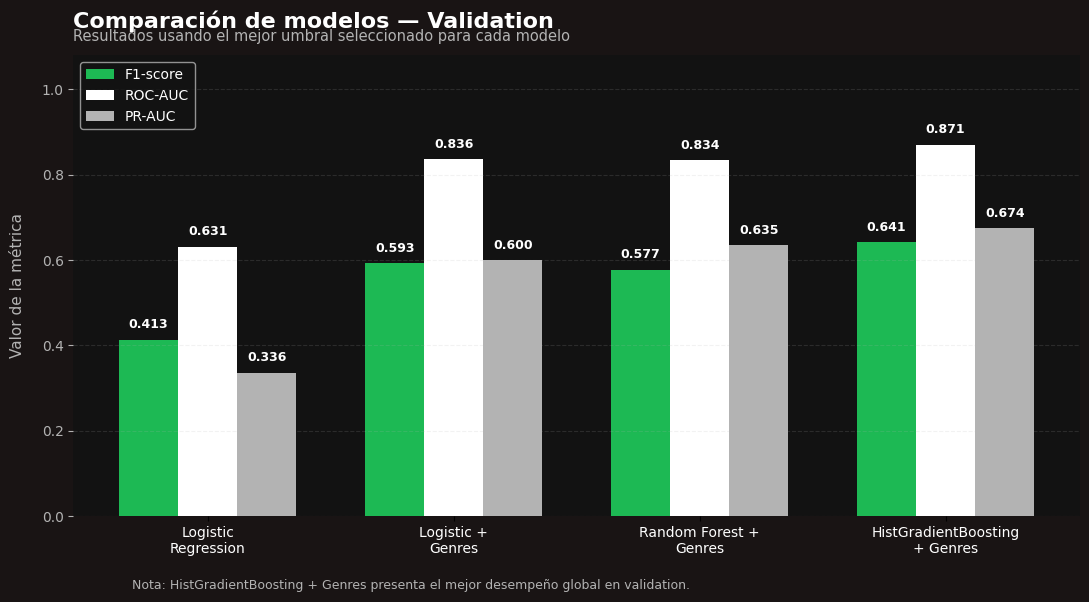

In [29]:
# Métricas principales
# Comparación visual de modelos — métricas principales

plot_models = best_models_comparison[
    best_models_comparison["Modelo"] != "DummyClassifier"
].copy()

metric_columns = ["F1-score", "ROC-AUC", "PR-AUC"]
x = np.arange(len(plot_models))
bar_width = 0.24

spotify_green = "#1DB954"
spotify_black = "#191414"
spotify_dark = "#121212"
spotify_gray = "#B3B3B3"
spotify_white = "#FFFFFF"

fig, ax = plt.subplots(figsize=(11, 6))

fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

bars_f1 = ax.bar(
    x - bar_width,
    plot_models["F1-score"],
    width=bar_width,
    label="F1-score",
    color=spotify_green
)

bars_roc = ax.bar(
    x,
    plot_models["ROC-AUC"],
    width=bar_width,
    label="ROC-AUC",
    color=spotify_white
)

bars_pr = ax.bar(
    x + bar_width,
    plot_models["PR-AUC"],
    width=bar_width,
    label="PR-AUC",
    color=spotify_gray
)

for bars in [bars_f1, bars_roc, bars_pr]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color=spotify_white
        )

ax.set_title(
    "Comparación de modelos — Validation",
    fontsize=16,
    fontweight="bold",
    color=spotify_white,
    loc="left",
    pad=20
)

ax.text(
    0,
    1.03,
    "Resultados usando el mejor umbral seleccionado para cada modelo",
    transform=ax.transAxes,
    fontsize=10.5,
    color=spotify_gray
)

ax.set_xticks(x)
ax.set_xticklabels(
    [
        "Logistic\nRegression",
        "Logistic +\nGenres",
        "Random Forest +\nGenres",
        "HistGradientBoosting\n+ Genres"
    ],
    fontsize=10,
    color=spotify_white
)

ax.set_ylim(0, 1.08)
ax.set_ylabel("Valor de la métrica", fontsize=11, color=spotify_gray, labelpad=12)
ax.tick_params(axis="y", colors=spotify_gray)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.16,
    color=spotify_gray
)

ax.legend(
    facecolor=spotify_dark,
    edgecolor=spotify_gray,
    labelcolor=spotify_white,
    loc="upper left"
)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(
    0.125,
    0.01,
    "Nota: HistGradientBoosting + Genres presenta el mejor desempeño global en validation.",
    fontsize=9,
    color=spotify_gray
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [31]:
# Tuning formal
from sklearn.model_selection import RandomizedSearchCV

## Optimización de hiperparámetros

Se realizará una búsqueda aleatoria de hiperparámetros para el modelo HistGradientBoosting.

La optimización se ejecutará únicamente sobre el conjunto de entrenamiento mediante validación cruzada de 3 folds. Se utilizará `average_precision` como métrica de selección, ya que el proyecto busca priorizar correctamente canciones populares en un escenario con clases desbalanceadas.

El conjunto de validation se conservará para evaluar el modelo optimizado y comparar su desempeño con la versión inicial.

In [32]:
from scipy.stats import randint, loguniform

# Espacio de hiperparámetros para HistGradientBoosting
param_distributions_hgb = {
    "learning_rate": loguniform(0.03, 0.15),
    "max_iter": randint(180, 401),
    "max_leaf_nodes": randint(15, 64),
    "min_samples_leaf": randint(10, 41),
    "l2_regularization": loguniform(0.01, 10.0)
}

hgb_base_for_tuning = HistGradientBoostingClassifier(
    class_weight="balanced",
    random_state=42
)

random_search_hgb = RandomizedSearchCV(
    estimator=hgb_base_for_tuning,
    param_distributions=param_distributions_hgb,
    n_iter=12,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

random_search_hgb.fit(X_train_dense, y_train)

print("Mejor PR-AUC promedio en cross-validation:",
      f"{random_search_hgb.best_score_:.4f}")

print("\nMejores hiperparámetros:")
print(random_search_hgb.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejor PR-AUC promedio en cross-validation: 0.6700

Mejores hiperparámetros:
{'l2_regularization': 0.014765043713594356, 'learning_rate': 0.09589075535858266, 'max_iter': 337, 'max_leaf_nodes': 52, 'min_samples_leaf': 11}


In [34]:
# Evaluación del HistGradientBoosting optimizado sobre validation

hgb_tuned_model = random_search_hgb.best_estimator_

y_val_pred_hgb_tuned = hgb_tuned_model.predict(X_val_dense)
y_val_proba_hgb_tuned = hgb_tuned_model.predict_proba(X_val_dense)[:, 1]

hgb_tuned_metrics = calculate_metrics(
    y_val,
    y_val_pred_hgb_tuned,
    y_val_proba_hgb_tuned,
    "HistGradientBoosting Tuned + Genres"
)

comparison_results_tuned = pd.DataFrame([
    hist_gradient_metrics,
    hgb_tuned_metrics
])

comparison_results_tuned.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}",
    "ROC-AUC": "{:.3f}",
    "PR-AUC": "{:.3f}"
})

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,HistGradientBoosting + Genres,77.88%,52.05%,80.86%,63.33%,0.871,0.674
1,HistGradientBoosting Tuned + Genres,78.35%,52.75%,80.48%,63.73%,0.874,0.685


### Resultado del tuning

La optimización mediante `RandomizedSearchCV` mejoró ligeramente el desempeño del modelo HistGradientBoosting.

En validation, el PR-AUC aumentó de 0,674 a 0,685 y el F1-score aumentó de 63,33% a 63,73%.

Por este motivo, la versión optimizada será utilizada como modelo candidato principal para las siguientes evaluaciones.

In [35]:
# Selección de umbral para HistGradientBoosting optimizado

thresholds = np.arange(0.30, 0.71, 0.05)
threshold_results_hgb_tuned = []

for threshold in thresholds:
    y_val_pred_threshold_hgb_tuned = (
        y_val_proba_hgb_tuned >= threshold
    ).astype(int)

    threshold_results_hgb_tuned.append({
        "Umbral": round(threshold, 2),
        "Precision": precision_score(
            y_val,
            y_val_pred_threshold_hgb_tuned,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            y_val_pred_threshold_hgb_tuned,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_val,
            y_val_pred_threshold_hgb_tuned,
            zero_division=0
        ),
        "Canciones_predichas_populares": int(
            y_val_pred_threshold_hgb_tuned.sum()
        )
    })

threshold_results_hgb_tuned = pd.DataFrame(threshold_results_hgb_tuned)

best_threshold_hgb_tuned = threshold_results_hgb_tuned.loc[
    threshold_results_hgb_tuned["F1-score"].idxmax()
]

print(
    f"Mejor umbral HGB optimizado: "
    f"{best_threshold_hgb_tuned['Umbral']:.2f} "
    f"| F1-score: {best_threshold_hgb_tuned['F1-score']:.2%}"
)

threshold_results_hgb_tuned.style.format({
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}"
})

Mejor umbral HGB optimizado: 0.55 | F1-score: 64.57%


,Umbral,Precision,Recall,F1-score,Canciones_predichas_populares
0,0.300000,41.13%,93.62%,57.15%,7240
1,0.350000,43.96%,91.80%,59.45%,6642
2,0.400000,46.51%,88.68%,61.01%,6066
3,0.450000,49.30%,84.82%,62.35%,5473
4,0.500000,52.75%,80.48%,63.73%,4853
5,0.550000,56.46%,75.39%,64.57%,4247
6,0.600000,60.14%,69.16%,64.34%,3658
7,0.650000,63.39%,61.62%,62.49%,3092
8,0.700000,67.75%,54.17%,60.20%,2543


In [36]:
# Métricas finales del modelo candidato en validation

selected_threshold_hgb_tuned = 0.55

y_val_pred_final_candidate = (
    y_val_proba_hgb_tuned >= selected_threshold_hgb_tuned
).astype(int)

final_candidate_metrics = calculate_metrics(
    y_val,
    y_val_pred_final_candidate,
    y_val_proba_hgb_tuned,
    "HistGradientBoosting Tuned + Genres"
)

print("Modelo candidato:", final_candidate_metrics["Modelo"])
print(f"Umbral seleccionado: {selected_threshold_hgb_tuned:.2f}")
print(f"Precision: {final_candidate_metrics['Precision']:.2%}")
print(f"Recall: {final_candidate_metrics['Recall']:.2%}")
print(f"F1-score: {final_candidate_metrics['F1-score']:.2%}")
print(f"ROC-AUC: {final_candidate_metrics['ROC-AUC']:.3f}")
print(f"PR-AUC: {final_candidate_metrics['PR-AUC']:.3f}")

Modelo candidato: HistGradientBoosting Tuned + Genres
Umbral seleccionado: 0.55
Precision: 56.46%
Recall: 75.39%
F1-score: 64.57%
ROC-AUC: 0.874
PR-AUC: 0.685


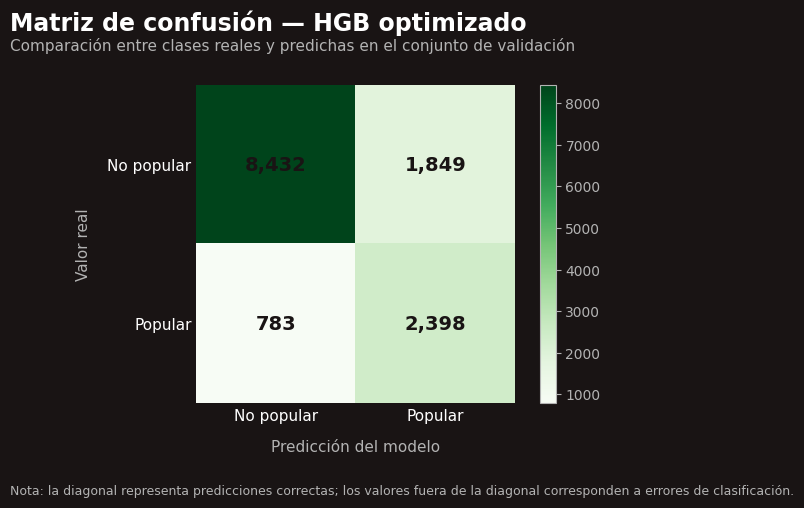

In [39]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Matriz de confusión del modelo candidato — validation
cm_hgb_tuned = confusion_matrix(y_val, y_val_pred_final_candidate)

spotify_green = "#1DB954"
spotify_black = "#191414"
spotify_dark = "#121212"
spotify_gray = "#B3B3B3"
spotify_white = "#FFFFFF"

fig, ax = plt.subplots(figsize=(7, 5))

# Fondos
fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

# Heatmap
image = ax.imshow(cm_hgb_tuned, cmap="Greens")

# Título y subtítulo
fig.text(
    0.125,
    0.96,
    "Matriz de confusión — HGB optimizado",
    color=spotify_white,
    fontsize=17,
    fontweight="bold"
)

fig.text(
    0.125,
    0.92,
    "Comparación entre clases reales y predichas en el conjunto de validación",
    color=spotify_gray,
    fontsize=11
)

# Etiquetas de ejes
ax.set_xlabel(
    "Predicción del modelo",
    fontsize=11,
    color=spotify_gray,
    labelpad=12
)

ax.set_ylabel(
    "Valor real",
    fontsize=11,
    color=spotify_gray,
    labelpad=12
)

# Ticks
ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["No popular", "Popular"],
    fontsize=11,
    color=spotify_white
)

ax.set_yticks([0, 1])
ax.set_yticklabels(
    ["No popular", "Popular"],
    fontsize=11,
    color=spotify_white
)

# Valores dentro de las celdas (todos negros)
for i in range(cm_hgb_tuned.shape[0]):
    for j in range(cm_hgb_tuned.shape[1]):
        value = cm_hgb_tuned[i, j]

        ax.text(
            j,
            i,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color=spotify_black
        )

# Colorbar
colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.ax.tick_params(colors=spotify_gray, labelsize=10)
colorbar.outline.set_edgecolor(spotify_gray)

# Quitar bordes y marcas
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0)

# Nota
fig.text(
    0.125,
    0.03,
    "Nota: la diagonal representa predicciones correctas; los valores fuera de la diagonal corresponden a errores de clasificación.",
    color=spotify_gray,
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 0.88])

plt.savefig(
    "../reports/figures/confusion_matrix_hgb_tuned_spotify_style.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

### Interpretación de la matriz de confusión

Con el umbral seleccionado de 0.55, el modelo identificó correctamente 2.398 canciones populares y 8.432 canciones no populares dentro del conjunto de validation.

El modelo dejó de detectar 783 canciones populares, correspondientes a falsos negativos. También clasificó 1.849 canciones no populares como posibles hits, correspondientes a falsos positivos.

Dado que el sistema se plantea como apoyo para priorizar canciones que serán revisadas por un equipo A&R, se acepta la existencia de falsos positivos moderados a cambio de mantener un recall de 75,39% para la detección de canciones populares.

## Simulación de impacto de negocio

El modelo no reemplaza la decisión del equipo A&R; funciona como una herramienta de priorización.

Para comparar umbrales, se simulará un escenario de negocio con valores ilustrativos:

- **Verdadero positivo (TP):** una canción popular correctamente priorizada genera un beneficio estimado de \$10.000.
- **Falso positivo (FP):** una canción no popular priorizada implica un costo de revisión, promoción inicial o recursos de \$2.000.
- **Falso negativo (FN):** no priorizar una canción que sí era popular representa un costo de oportunidad estimado de \$8.000.
- **Verdadero negativo (TN):** no genera beneficio ni costo directo en esta simulación.

Estos valores son supuestos académicos y se usarán únicamente para comparar decisiones entre umbrales.

In [40]:
# Simulación de impacto de negocio para distintos umbrales
# Valores ilustrativos en dólares

business_values = {
    "TP": 10000,
    "FP": -2000,
    "FN": -8000,
    "TN": 0
}

business_impact_results = []

for threshold in thresholds:
    y_pred_business = (y_val_proba_hgb_tuned >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_business).ravel()

    estimated_impact = (
        tp * business_values["TP"]
        + fp * business_values["FP"]
        + fn * business_values["FN"]
        + tn * business_values["TN"]
    )

    business_impact_results.append({
        "Umbral": round(threshold, 2),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Impacto_estimado_USD": estimated_impact
    })

business_impact_results = pd.DataFrame(business_impact_results)

best_business_threshold = business_impact_results.loc[
    business_impact_results["Impacto_estimado_USD"].idxmax()
]

print(
    f"Mejor umbral por impacto de negocio: "
    f"{best_business_threshold['Umbral']:.2f}"
)

print(
    f"Impacto estimado: "
    f"${best_business_threshold['Impacto_estimado_USD']:,.0f}"
)

business_impact_results.style.format({
    "Impacto_estimado_USD": "${:,.0f}"
})

Mejor umbral por impacto de negocio: 0.35
Impacto estimado: $19,668,000


,Umbral,TP,FP,FN,TN,Impacto_estimado_USD
0,0.300000,2978,4262,203,6019,"$19,632,000"
1,0.350000,2920,3722,261,6559,"$19,668,000"
2,0.400000,2821,3245,360,7036,"$18,840,000"
3,0.450000,2698,2775,483,7506,"$17,566,000"
4,0.500000,2560,2293,621,7988,"$16,046,000"
5,0.550000,2398,1849,783,8432,"$14,018,000"
6,0.600000,2200,1458,981,8823,"$11,236,000"
7,0.650000,1960,1132,1221,9149,"$7,568,000"
8,0.700000,1723,820,1458,9461,"$3,926,000"


### Decisión de umbral basada en impacto de negocio

La selección de umbral depende del objetivo de negocio.

El umbral de 0.55 maximiza el F1-score y ofrece un equilibrio entre precision y recall. Sin embargo, bajo los supuestos de impacto definidos para esta simulación, el umbral de 0.35 genera el mayor beneficio estimado.

Esto ocurre porque el costo de oportunidad de no priorizar una canción popular es mayor que el costo de revisar o promocionar inicialmente una canción que finalmente no alcanza el umbral de popularidad.

Por tanto, se plantean dos escenarios de uso:

- **Estrategia equilibrada:** umbral de 0.55, recomendado cuando el equipo tiene capacidad limitada de revisión.
- **Estrategia de descubrimiento:** umbral de 0.35, recomendado cuando se busca maximizar la detección temprana de posibles hits y existe mayor capacidad de revisión humana.

La decisión final deberá validarse con el equipo de negocio y con datos reales de costos, presupuesto y capacidad operativa.

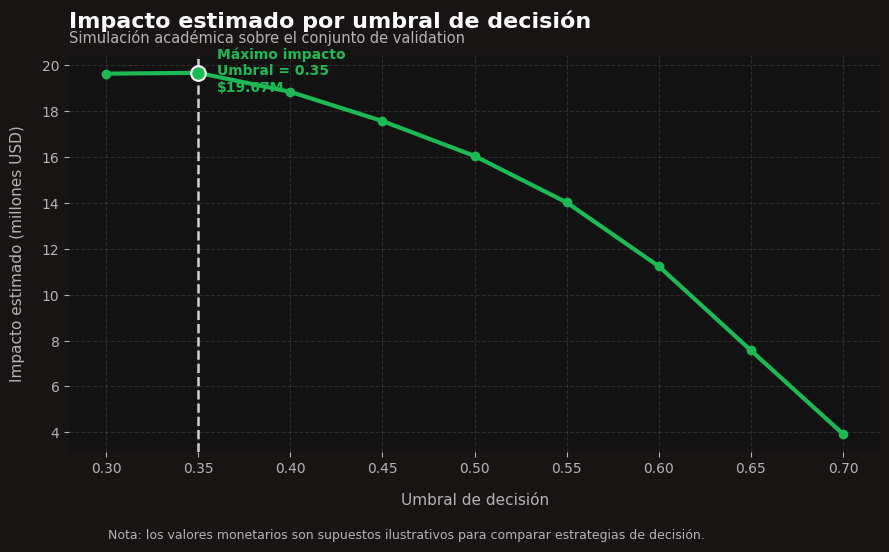

In [41]:
# Impacto de negocio por umbral — HistGradientBoosting optimizado

fig, ax = plt.subplots(figsize=(9, 5.5))

fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

ax.plot(
    business_impact_results["Umbral"],
    business_impact_results["Impacto_estimado_USD"] / 1_000_000,
    marker="o",
    linewidth=3,
    color=spotify_green
)

ax.axvline(
    best_business_threshold["Umbral"],
    linestyle="--",
    linewidth=1.8,
    color=spotify_white,
    alpha=0.8
)

ax.scatter(
    best_business_threshold["Umbral"],
    best_business_threshold["Impacto_estimado_USD"] / 1_000_000,
    s=110,
    color=spotify_green,
    edgecolor=spotify_white,
    linewidth=1.5,
    zorder=3
)

ax.text(
    best_business_threshold["Umbral"] + 0.01,
    best_business_threshold["Impacto_estimado_USD"] / 1_000_000 - 0.8,
    (
        f"Máximo impacto\n"
        f"Umbral = {best_business_threshold['Umbral']:.2f}\n"
        f"${best_business_threshold['Impacto_estimado_USD'] / 1_000_000:.2f}M"
    ),
    fontsize=10,
    fontweight="bold",
    color=spotify_green
)

ax.set_title(
    "Impacto estimado por umbral de decisión",
    fontsize=16,
    fontweight="bold",
    color=spotify_white,
    loc="left",
    pad=20
)

ax.text(
    0,
    1.03,
    "Simulación académica sobre el conjunto de validation",
    transform=ax.transAxes,
    fontsize=10.5,
    color=spotify_gray
)

ax.set_xlabel(
    "Umbral de decisión",
    fontsize=11,
    color=spotify_gray,
    labelpad=12
)

ax.set_ylabel(
    "Impacto estimado (millones USD)",
    fontsize=11,
    color=spotify_gray,
    labelpad=12
)

ax.set_xticks(business_impact_results["Umbral"])
ax.tick_params(colors=spotify_gray)

ax.grid(
    alpha=0.16,
    color=spotify_gray,
    linestyle="--"
)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(
    0.125,
    0.01,
    "Nota: los valores monetarios son supuestos ilustrativos para comparar estrategias de decisión.",
    fontsize=9,
    color=spotify_gray
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## Evaluación de fairness por género musical

Se evaluará el desempeño del modelo candidato entre distintos grupos de género.

La evaluación se realiza sobre validation y utiliza el umbral de negocio de `0.35`. Como una canción puede pertenecer a varios géneros, se analizarán los géneros principales con suficiente número de observaciones.

Se compararán principalmente precision, recall, F1-score y tasa de predicción positiva por género.

In [42]:
# Fairness por género en validation
# Se usa el umbral que maximiza el impacto de negocio.

selected_business_threshold = float(best_business_threshold["Umbral"])

y_val_pred_business = (
    y_val_proba_hgb_tuned >= selected_business_threshold
).astype(int)

fairness_validation = X_val[["genres"]].copy()
fairness_validation["popular_real"] = y_val.values
fairness_validation["popular_predicho"] = y_val_pred_business

# Una fila por canción-género para poder analizar cada género
fairness_by_genre = (
    fairness_validation
    .assign(genre=fairness_validation["genres"].str.split("|"))
    .explode("genre")
    .drop(columns="genres")
)

genre_counts = fairness_by_genre["genre"].value_counts()

# Solo se analizan géneros con al menos 100 canciones en validation
eligible_genres = genre_counts[genre_counts >= 100].index

fairness_results = []

for genre in eligible_genres:
    group = fairness_by_genre[fairness_by_genre["genre"] == genre]

    fairness_results.append({
        "Género": genre,
        "Canciones": len(group),
        "Tasa_real_popular": group["popular_real"].mean(),
        "Tasa_predicha_popular": group["popular_predicho"].mean(),
        "Precision": precision_score(
            group["popular_real"],
            group["popular_predicho"],
            zero_division=0
        ),
        "Recall": recall_score(
            group["popular_real"],
            group["popular_predicho"],
            zero_division=0
        ),
        "F1-score": f1_score(
            group["popular_real"],
            group["popular_predicho"],
            zero_division=0
        )
    })

fairness_results = (
    pd.DataFrame(fairness_results)
    .sort_values("Canciones", ascending=False)
    .reset_index(drop=True)
)

fairness_results.head(15).style.format({
    "Tasa_real_popular": "{:.2%}",
    "Tasa_predicha_popular": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}"
})

,Género,Canciones,Tasa_real_popular,Tasa_predicha_popular,Precision,Recall,F1-score
0,hardstyle,183,8.74%,33.33%,19.67%,75.00%,31.17%
1,j-idol,175,2.29%,1.71%,33.33%,25.00%,28.57%
2,guitar,173,1.73%,4.05%,0.00%,0.00%,0.00%
3,pop,171,66.67%,91.81%,72.61%,100.00%,84.13%
4,samba,171,1.17%,0.58%,0.00%,0.00%,0.00%
5,sad,169,74.56%,100.00%,74.56%,100.00%,85.42%
6,progressive-house,167,65.87%,100.00%,65.87%,100.00%,79.42%
7,edm,164,46.95%,92.07%,50.33%,98.70%,66.67%
8,chill,162,72.84%,100.00%,72.84%,100.00%,84.29%
9,turkish,162,4.32%,2.47%,25.00%,14.29%,18.18%


In [43]:
# Fairness más robusto:
# se excluyen grupos con muy pocos casos positivos reales.

fairness_results_robust = fairness_results.copy()

positive_counts_by_genre = (
    fairness_by_genre
    .groupby("genre")["popular_real"]
    .sum()
    .rename("Populares_reales")
    .reset_index()
    .rename(columns={"genre": "Género"})
)

fairness_results_robust = fairness_results_robust.merge(
    positive_counts_by_genre,
    on="Género",
    how="left"
)

fairness_results_robust = (
    fairness_results_robust[
        (fairness_results_robust["Canciones"] >= 100)
        & (fairness_results_robust["Populares_reales"] >= 20)
    ]
    .sort_values("F1-score", ascending=False)
    .reset_index(drop=True)
)

print(
    "Géneros evaluados con soporte suficiente:",
    len(fairness_results_robust)
)

fairness_results_robust[
    [
        "Género",
        "Canciones",
        "Populares_reales",
        "Tasa_real_popular",
        "Tasa_predicha_popular",
        "Precision",
        "Recall",
        "F1-score"
    ]
].style.format({
    "Tasa_real_popular": "{:.2%}",
    "Tasa_predicha_popular": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}"
})

Géneros evaluados con soporte suficiente: 73


,Género,Canciones,Populares_reales,Tasa_real_popular,Tasa_predicha_popular,Precision,Recall,F1-score
0,pop-film,151,142,94.04%,100.00%,94.04%,100.00%,96.93%
1,hip-hop,138,88,63.77%,84.78%,75.21%,100.00%,85.85%
2,sad,169,126,74.56%,100.00%,74.56%,100.00%,85.42%
3,k-pop,134,98,73.13%,98.51%,74.24%,100.00%,85.22%
4,chill,162,118,72.84%,100.00%,72.84%,100.00%,84.29%
5,pop,171,114,66.67%,91.81%,72.61%,100.00%,84.13%
6,grunge,144,100,69.44%,98.61%,70.42%,100.00%,82.64%
7,progressive-house,167,110,65.87%,100.00%,65.87%,100.00%,79.42%
8,british,150,91,60.67%,94.67%,63.38%,98.90%,77.25%
9,deep-house,151,91,60.26%,97.35%,61.90%,100.00%,76.47%


In [44]:
# Brechas de desempeño por género respecto al resultado global

global_precision_business = precision_score(
    y_val,
    y_val_pred_business,
    zero_division=0
)

global_recall_business = recall_score(
    y_val,
    y_val_pred_business,
    zero_division=0
)

global_f1_business = f1_score(
    y_val,
    y_val_pred_business,
    zero_division=0
)

fairness_results_robust["Brecha_precision"] = (
    fairness_results_robust["Precision"] - global_precision_business
)

fairness_results_robust["Brecha_recall"] = (
    fairness_results_robust["Recall"] - global_recall_business
)

fairness_results_robust["Brecha_f1"] = (
    fairness_results_robust["F1-score"] - global_f1_business
)

print(f"Precision global: {global_precision_business:.2%}")
print(f"Recall global: {global_recall_business:.2%}")
print(f"F1-score global: {global_f1_business:.2%}")

fairness_results_robust[
    [
        "Género",
        "Canciones",
        "Populares_reales",
        "Precision",
        "Recall",
        "F1-score",
        "Brecha_f1"
    ]
].sort_values("Brecha_f1").head(10).style.format({
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}",
    "Brecha_f1": "{:+.2%}"
})

Precision global: 43.96%
Recall global: 91.80%
F1-score global: 59.45%


,Género,Canciones,Populares_reales,Precision,Recall,F1-score,Brecha_f1
72,pagode,160,23,15.79%,65.22%,25.42%,-34.03%
71,country,148,23,18.81%,82.61%,30.65%,-28.81%
70,drum-and-bass,156,20,21.43%,60.00%,31.58%,-27.87%
69,funk,146,30,24.11%,90.00%,38.03%,-21.42%
68,sertanejo,131,29,23.93%,96.55%,38.36%,-21.10%
67,cantopop,144,22,27.27%,68.18%,38.96%,-20.49%
66,show-tunes,129,23,24.73%,100.00%,39.66%,-19.80%
65,children,160,38,26.28%,94.74%,41.14%,-18.31%
64,swedish,151,35,27.68%,88.57%,42.18%,-17.28%
63,dub,153,38,29.29%,76.32%,42.34%,-17.12%


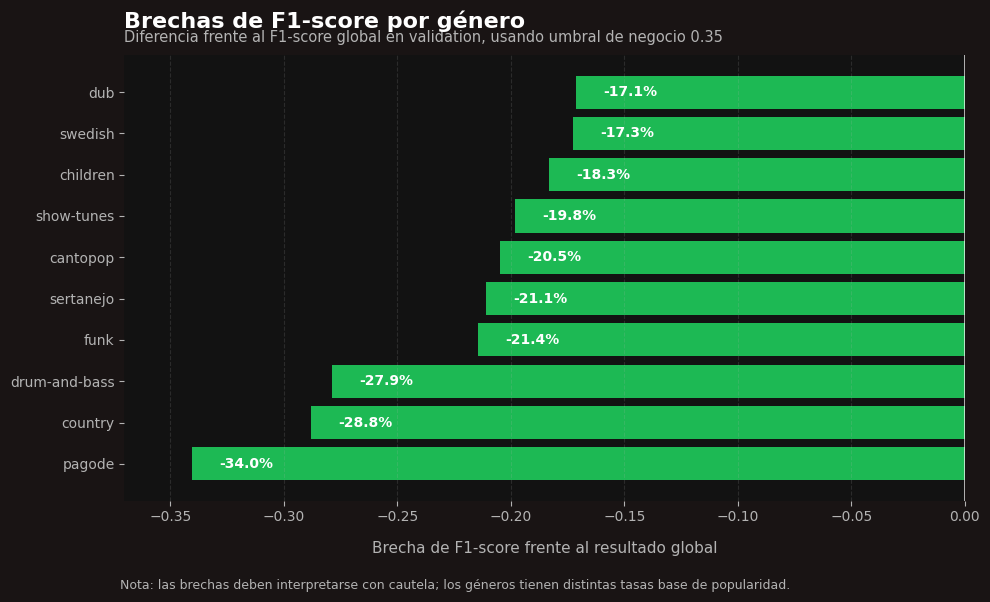

In [46]:
# Fairness por género: 10 mayores brechas negativas de F1-score

fairness_plot = (
    fairness_results_robust
    .sort_values("Brecha_f1")
    .head(10)
    .sort_values("Brecha_f1", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

ax.barh(
    fairness_plot["Género"],
    fairness_plot["Brecha_f1"],
    color=spotify_green
)

ax.axvline(
    0,
    color=spotify_white,
    linewidth=1.2,
    alpha=0.8
)

for index, value in enumerate(fairness_plot["Brecha_f1"]):
    ax.text(
        value + 0.012,
        index,
        f"{value:.1%}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=spotify_white
    )

ax.set_title(
    "Brechas de F1-score por género",
    fontsize=16,
    fontweight="bold",
    color=spotify_white,
    loc="left",
    pad=20
)

ax.text(
    0,
    1.03,
    "Diferencia frente al F1-score global en validation, usando umbral de negocio 0.35",
    transform=ax.transAxes,
    fontsize=10.5,
    color=spotify_gray
)

ax.set_xlabel(
    "Brecha de F1-score frente al resultado global",
    fontsize=11,
    color=spotify_gray,
    labelpad=12
)

ax.set_ylabel("")
ax.tick_params(colors=spotify_gray)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.16,
    color=spotify_gray
)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(
    0.125,
    0.01,
    "Nota: las brechas deben interpretarse con cautela; los géneros tienen distintas tasas base de popularidad.",
    fontsize=9,
    color=spotify_gray
)
ax.set_xlim(fairness_plot["Brecha_f1"].min() - 0.03, 0)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

### Hallazgos de fairness por género

La evaluación por género se realizó sobre el conjunto de validation, utilizando el umbral de negocio de `0.35`.

Para reducir conclusiones inestables, solo se consideraron géneros con al menos 100 canciones y 20 canciones populares reales. Bajo este criterio se evaluaron 73 géneros.

Se identificaron diferencias de desempeño entre grupos musicales. Los géneros con mayor brecha negativa de F1-score frente al resultado global fueron:

- `pagode`: −34,03 puntos porcentuales.
- `country`: −28,81 puntos porcentuales.
- `drum-and-bass`: −27,87 puntos porcentuales.
- `funk`: −21,42 puntos porcentuales.
- `sertanejo`: −21,10 puntos porcentuales.

Estas diferencias no deben interpretarse automáticamente como discriminación, ya que los géneros musicales no son atributos personales protegidos y presentan tasas base de popularidad muy distintas.

Sin embargo, representan un riesgo de cobertura del modelo: algunos géneros pueden recibir recomendaciones menos precisas que otros. Por ello, el modelo debe utilizarse como apoyo para priorización y no como criterio automático de inversión.

Como medida de mitigación, se recomienda monitorear las métricas por género en cada nueva versión del modelo y aplicar revisión humana adicional en géneros con desempeño históricamente bajo.